In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import joblib

## 1) File paths and class map

In [ ]:
DATA_DIR = Path("../data/raw")

FILES = {
    "rest/rest_stressed_20260406_170652.csv": "rest",
    "moderate/moderate_walking_20260407_120447.csv": "moderate",
    "moderate/moderate_stairs_20260411_224148.csv": "moderate",   
    "intense/intense_running_20260414_195242.csv": "intense",
    "intense/intense_squats_20260411_223205.csv": "intense",
}

LABEL_MAP = {
    "rest": 0,
    "moderate": 1,
    "intense": 2
}


C:\Users\vPro\OneDrive - Al Akhawayn University in Ifrane\AUI\capstone\capstone\ml_pipeline\data\raw
[WindowsPath('../data/raw/intense/intense_running_20260414_195242.csv'), WindowsPath('../data/raw/intense/intense_squats_20260411_223205.csv'), WindowsPath('../data/raw/moderate/moderate_stairs_20260411_224148.csv'), WindowsPath('../data/raw/moderate/moderate_walking_20260407_120447.csv'), WindowsPath('../data/raw/rest/rest_a little stressed_20260406_170150.csv'), WindowsPath('../data/raw/rest/rest_stressed_20260406_170652.csv'), WindowsPath('../data/raw/WESAD/S10/S10_quest.csv'), WindowsPath('../data/raw/WESAD/S11/S11_quest.csv'), WindowsPath('../data/raw/WESAD/S13/S13_quest.csv'), WindowsPath('../data/raw/WESAD/S14/S14_quest.csv'), WindowsPath('../data/raw/WESAD/S15/S15_quest.csv'), WindowsPath('../data/raw/WESAD/S16/S16_quest.csv'), WindowsPath('../data/raw/WESAD/S17/S17_quest.csv'), WindowsPath('../data/raw/WESAD/S2/S2_quest.csv'), WindowsPath('../data/raw/WESAD/S3/S3_quest.csv'), W

## 2) Load and clean each file

In [16]:
def load_and_clean_csv(file_path, class_label):
    df = pd.read_csv(file_path)

    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.sort_values("timestamp").reset_index(drop=True)

    df["activity"] = class_label

    numeric_cols = ["temp", "emg_raw", "emg_env", "emg_state", "ax", "ay", "az", "hr"]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df.loc[df["hr"] <= 0, "hr"] = np.nan

    df["hr"] = df["hr"].interpolate(limit_direction="both")
    df["hr"] = df["hr"].ffill().bfill()

    for col in numeric_cols:
        df[col] = df[col].interpolate(limit_direction="both")
        df[col] = df[col].ffill().bfill()

    df["acc_mag"] = np.sqrt(df["ax"]**2 + df["ay"]**2 + df["az"]**2)

    df["dt"] = df["timestamp"].diff().dt.total_seconds()
    median_dt = df["dt"].median()
    df["dt"] = df["dt"].fillna(median_dt if pd.notna(median_dt) else 1.0)

    return df

## 3) Load all files

In [17]:
all_dfs = []

for fname, cls in FILES.items():
    path = DATA_DIR / fname
    print(path)
    df = load_and_clean_csv(path, cls)
    df["source_file"] = fname
    all_dfs.append(df)

full_df = pd.concat(all_dfs, ignore_index=True)

print(full_df.shape)
print(full_df[["source_file", "activity"]].drop_duplicates())
full_df.head()

..\data\raw\rest\rest_stressed_20260406_170652.csv
..\data\raw\moderate\moderate_walking_20260407_120447.csv
..\data\raw\moderate\moderate_stairs_20260411_224148.csv
..\data\raw\intense\intense_running_20260414_195242.csv
..\data\raw\intense\intense_squats_20260411_223205.csv
(1231, 14)
                                        source_file  activity
0            rest/rest_stressed_20260406_170652.csv      rest
331   moderate/moderate_walking_20260407_120447.csv  moderate
658    moderate/moderate_stairs_20260411_224148.csv  moderate
782     intense/intense_running_20260414_195242.csv   intense
1135     intense/intense_squats_20260411_223205.csv   intense


,timestamp,label,temp,emg_raw,emg_env,emg_state,ax,ay,az,hr,activity,acc_mag,dt,source_file
0,2026-04-06 17:07:15.063368,rest,29.87,47.0,14.0,0.0,16884.0,-524.0,720.0,106.0,rest,16907.466753,1.035213,rest/rest_stressed_20260406_170652.csv
1,2026-04-06 17:07:16.098730,rest,29.87,69.0,16.0,1.0,16952.0,-460.0,744.0,106.0,rest,16974.552719,1.035362,rest/rest_stressed_20260406_170652.csv
2,2026-04-06 17:07:17.132831,rest,29.87,53.0,15.0,0.0,16916.0,-436.0,692.0,105.0,rest,16935.761453,1.034101,rest/rest_stressed_20260406_170652.csv
3,2026-04-06 17:07:18.168232,rest,29.87,62.0,13.0,0.0,16872.0,-492.0,636.0,103.0,rest,16891.149872,1.035401,rest/rest_stressed_20260406_170652.csv
4,2026-04-06 17:07:19.202292,rest,29.94,55.0,14.0,0.0,16956.0,-508.0,700.0,101.0,rest,16978.044646,1.034060,rest/rest_stressed_20260406_170652.csv


## 4) Window feature extraction

In [18]:
WINDOW_SEC = 10
STEP_SEC = 5

def waveform_length(x):
    x = np.asarray(x)
    if len(x) < 2:
        return 0.0
    return np.sum(np.abs(np.diff(x)))

def zero_crossings(x):
    x = np.asarray(x)
    if len(x) < 2:
        return 0
    x_centered = x - np.mean(x)
    return np.sum(np.diff(np.sign(x_centered)) != 0)

def slope_feature(x):
    x = np.asarray(x)
    if len(x) < 2:
        return 0.0
    return (x[-1] - x[0]) / len(x)

def extract_features_from_window(win):
    feats = {}

    # HR
    feats["hr_mean"] = win["hr"].mean()
    feats["hr_std"] = win["hr"].std()
    feats["hr_min"] = win["hr"].min()
    feats["hr_max"] = win["hr"].max()
    feats["hr_range"] = feats["hr_max"] - feats["hr_min"]

    # Temperature
    feats["temp_mean"] = win["temp"].mean()
    feats["temp_std"] = win["temp"].std()
    feats["temp_min"] = win["temp"].min()
    feats["temp_max"] = win["temp"].max()
    feats["temp_slope"] = slope_feature(win["temp"].values)

    # EMG
    feats["emg_raw_mean"] = win["emg_raw"].mean()
    feats["emg_raw_std"] = win["emg_raw"].std()
    feats["emg_env_mean"] = win["emg_env"].mean()
    feats["emg_env_std"] = win["emg_env"].std()
    feats["emg_rms"] = np.sqrt(np.mean(win["emg_raw"].values**2))
    feats["emg_mav"] = np.mean(np.abs(win["emg_raw"].values))
    feats["emg_wl"] = waveform_length(win["emg_raw"].values)
    feats["emg_zero_cross"] = zero_crossings(win["emg_raw"].values)
    feats["emg_state_mean"] = win["emg_state"].mean()

    # IMU axis stats
    for axis in ["ax", "ay", "az"]:
        feats[f"{axis}_mean"] = win[axis].mean()
        feats[f"{axis}_std"] = win[axis].std()
        feats[f"{axis}_min"] = win[axis].min()
        feats[f"{axis}_max"] = win[axis].max()

    # Magnitude stats
    feats["acc_mag_mean"] = win["acc_mag"].mean()
    feats["acc_mag_std"] = win["acc_mag"].std()
    feats["acc_mag_min"] = win["acc_mag"].min()
    feats["acc_mag_max"] = win["acc_mag"].max()
    feats["acc_mag_range"] = feats["acc_mag_max"] - feats["acc_mag_min"]
    feats["acc_mag_energy"] = np.mean(win["acc_mag"].values**2)

    # Jerk from magnitude
    if len(win) > 1:
        jerk = np.diff(win["acc_mag"].values)
        feats["jerk_mean"] = np.mean(np.abs(jerk))
        feats["jerk_std"] = np.std(jerk)
    else:
        feats["jerk_mean"] = 0.0
        feats["jerk_std"] = 0.0

    return feats

In [19]:
def build_windowed_dataset(df, window_sec=10, step_sec=5):
    rows = []

    for source_file, g in df.groupby("source_file"):
        g = g.sort_values("timestamp").reset_index(drop=True)

        start_time = g["timestamp"].min()
        end_time = g["timestamp"].max()

        t = start_time
        while t + pd.Timedelta(seconds=window_sec) <= end_time:
            w_end = t + pd.Timedelta(seconds=window_sec)
            win = g[(g["timestamp"] >= t) & (g["timestamp"] < w_end)].copy()

            # Require enough points
            if len(win) >= max(5, window_sec // 2):
                feats = extract_features_from_window(win)
                feats["label_name"] = win["activity"].iloc[0]
                feats["label"] = LABEL_MAP[win["activity"].iloc[0]]
                feats["source_file"] = source_file
                feats["window_start"] = t
                feats["window_end"] = w_end
                feats["n_samples"] = len(win)
                rows.append(feats)

            t += pd.Timedelta(seconds=step_sec)

    return pd.DataFrame(rows)

In [20]:
def build_windowed_dataset(df, window_sec=10, step_sec=5):
    rows = []

    for source_file, g in df.groupby("source_file"):
        g = g.sort_values("timestamp").reset_index(drop=True)

        start_time = g["timestamp"].min()
        end_time = g["timestamp"].max()

        t = start_time
        while t + pd.Timedelta(seconds=window_sec) <= end_time:
            w_end = t + pd.Timedelta(seconds=window_sec)
            win = g[(g["timestamp"] >= t) & (g["timestamp"] < w_end)].copy()

            # Require enough points
            if len(win) >= max(5, window_sec // 2):
                feats = extract_features_from_window(win)
                feats["label_name"] = win["activity"].iloc[0]
                feats["label"] = LABEL_MAP[win["activity"].iloc[0]]
                feats["source_file"] = source_file
                feats["window_start"] = t
                feats["window_end"] = w_end
                feats["n_samples"] = len(win)
                rows.append(feats)

            t += pd.Timedelta(seconds=step_sec)

    return pd.DataFrame(rows)

In [21]:
features_df = build_windowed_dataset(full_df, window_sec=WINDOW_SEC, step_sec=STEP_SEC)

print(features_df.shape)
print(features_df["label_name"].value_counts())
features_df.head()

(247, 45)
label_name
intense     90
moderate    90
rest        67
Name: count, dtype: int64


,hr_mean,hr_std,hr_min,hr_max,hr_range,temp_mean,temp_std,temp_min,temp_max,temp_slope,...,acc_mag_range,acc_mag_energy,jerk_mean,jerk_std,label_name,label,source_file,window_start,window_end,n_samples
0,97.300000,2.213594,94.0,101.0,7.0,27.723000,0.102746,27.56,27.87,-0.031000,...,2041.468517,3.373528e+08,614.065686,866.594422,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:17.519406,2026-04-14 19:53:27.519406,10
1,100.400000,3.893014,94.0,106.0,12.0,27.549000,0.117327,27.31,27.69,-0.038000,...,17123.972411,3.851633e+08,6623.889893,9265.482858,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:22.519406,2026-04-14 19:53:32.519406,10
2,105.900000,2.998148,101.0,109.0,8.0,27.275000,0.224314,26.94,27.56,-0.062000,...,17747.568929,3.820010e+08,11053.029205,11543.581328,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:27.519406,2026-04-14 19:53:37.519406,10
3,107.000000,1.632993,105.0,109.0,4.0,26.906000,0.225152,26.56,27.25,-0.069000,...,22243.470463,4.459598e+08,11270.565983,11857.971996,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:32.519406,2026-04-14 19:53:42.519406,10
4,107.888889,3.551213,105.0,114.0,9.0,26.582222,0.195114,26.31,26.87,-0.062222,...,21984.351951,5.460429e+08,13962.586061,14692.866503,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:37.519406,2026-04-14 19:53:47.519406,9


## 5) Prepare X and y

In [22]:
drop_cols = ["label_name", "label", "source_file", "window_start", "window_end"]
X = features_df.drop(columns=drop_cols)
y = features_df["label"]

# Fill any std NaNs caused by tiny windows
X = X.fillna(0)

print(X.shape)
print(y.value_counts())

(247, 40)
label
2    90
1    90
0    67
Name: count, dtype: int64


## 6) Train/test split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(185, 40) (62, 40)


## 7) Train Random Forest

In [24]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=["rest", "moderate", "intense"]
))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

        rest       1.00      1.00      1.00        17
    moderate       1.00      1.00      1.00        23
     intense       1.00      1.00      1.00        22

    accuracy                           1.00        62
   macro avg       1.00      1.00      1.00        62
weighted avg       1.00      1.00      1.00        62



## 8) Confusion matrix

[[17  0  0]
 [ 0 23  0]
 [ 0  0 22]]


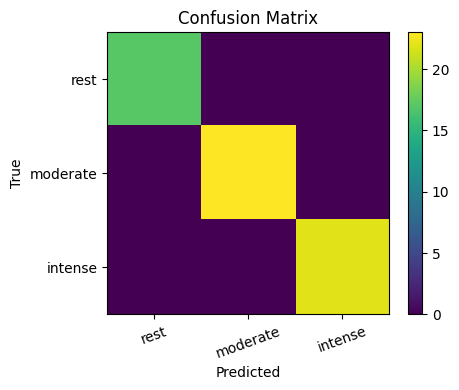

In [25]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1, 2], ["rest", "moderate", "intense"], rotation=20)
plt.yticks([0, 1, 2], ["rest", "moderate", "intense"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## 9) Feature importance

emg_env_mean     0.096976
ax_std           0.090085
ax_mean          0.064469
ax_min           0.064039
emg_mav          0.054151
ay_std           0.052344
acc_mag_range    0.050174
jerk_std         0.048010
emg_raw_mean     0.047677
az_std           0.047474
jerk_mean        0.045392
acc_mag_std      0.041895
temp_mean        0.037793
temp_max         0.034308
temp_min         0.033242
acc_mag_max      0.031424
emg_rms          0.030901
az_min           0.017951
ay_mean          0.016022
az_mean          0.015343
dtype: float64


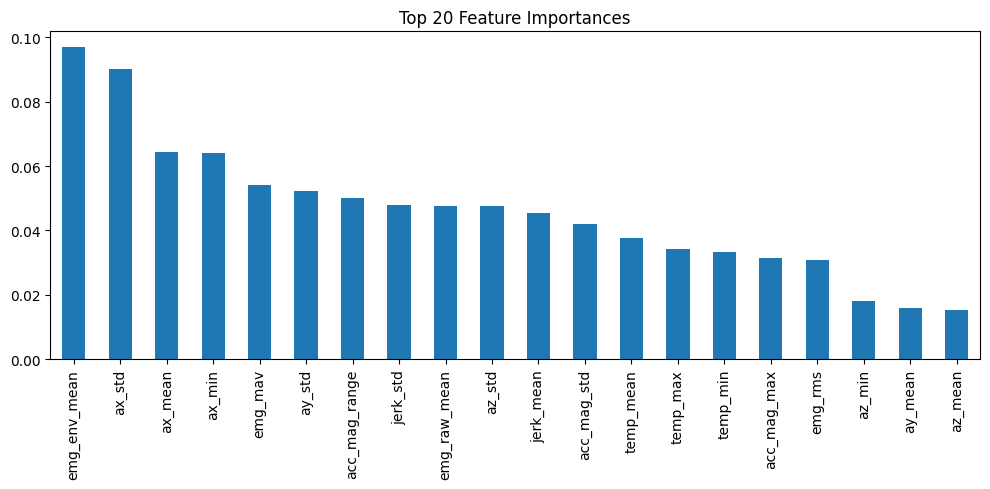

In [26]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print(importances.head(20))

plt.figure(figsize=(10, 5))
importances.head(20).plot(kind="bar")
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

## 10) Save outputs

In [27]:
from pathlib import Path
import joblib

Path("../data/processed").mkdir(parents=True, exist_ok=True)
Path("../models/classical").mkdir(parents=True, exist_ok=True)

features_df.to_csv("../data/processed/activity_fusion_features_sensors.csv", index=False)
joblib.dump(rf, "../models/classical/activity_classifier_rf_sensors.pkl")

print("Saved successfully.")

Saved successfully.


## 11) Optional: leave-one-file-out style check

In [28]:
features_df[["source_file", "label_name"]].value_counts()

source_file                                    label_name
intense/intense_running_20260414_195242.csv    intense       72
rest/rest_stressed_20260406_170652.csv         rest          67
moderate/moderate_walking_20260407_120447.csv  moderate      66
moderate/moderate_stairs_20260411_224148.csv   moderate      24
intense/intense_squats_20260411_223205.csv     intense       18
Name: count, dtype: int64